## Creates the **Epidemiological Timeline** for a specific region by using the available data on WNV Cases ##

In [1]:
import pandas as pd
import itertools
import sys
sys.path.insert(0, "../../Modules")

from utils import *

enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 10

In [2]:
NUTS0 = 'GR'

## 2010 - 2021 ##

In [3]:
data = pd.read_csv(f'../data/{NUTS0}_WNV_cases_grid_2010-2021_processed.csv', encoding = enc)
data.head(5)

,age,sex,onset of symptoms,year,month,day,nuts2,nuts3,lau1,lau2,cell_code
0,75,f,2010-07-28,2010,7,28,κεντρικης μακεδονιας,θεσσαλονικης,θεσσαλονικης,"παπαφη, θεσσαλονικη",DW307
1,78,m,2010-07-22,2010,7,22,κεντρικης μακεδονιας,ημαθιας,βεροιας,βεροια,EI242
2,70,f,2010-07-24,2010,7,24,κεντρικης μακεδονιας,κιλκις,κιλκις,λεβεντοχωρι,CN297
3,74,m,2010-07-30,2010,7,30,κεντρικης μακεδονιας,κιλκις,κιλκις,καμπανη,CU305
4,19,f,2010-07-06,2010,7,6,κεντρικης μακεδονιας,σερρων,ηρακλειας,ποντισμενο,BL336


In [4]:
data['period'] = data.apply(lambda row: 1 if (row['day']>=1 and row['day']<=15) else 2, axis = 1)
data['dt_placement'] = data.apply(lambda row: f"{row['year']:04}-{row['month']:02}-{1 if row['period'] == 1 else 16:02}", axis = 1)

data['dt_placement']= pd.to_datetime(data['dt_placement'])
data['case'] = 1

In [5]:
data


,age,sex,onset of symptoms,year,month,day,nuts2,nuts3,lau1,lau2,cell_code,period,dt_placement,case
0,75,f,2010-07-28,2010,7,28,κεντρικης μακεδονιας,θεσσαλονικης,θεσσαλονικης,"παπαφη, θεσσαλονικη",DW307,2,2010-07-16,1
1,78,m,2010-07-22,2010,7,22,κεντρικης μακεδονιας,ημαθιας,βεροιας,βεροια,EI242,2,2010-07-16,1
2,70,f,2010-07-24,2010,7,24,κεντρικης μακεδονιας,κιλκις,κιλκις,λεβεντοχωρι,CN297,2,2010-07-16,1
3,74,m,2010-07-30,2010,7,30,κεντρικης μακεδονιας,κιλκις,κιλκις,καμπανη,CU305,2,2010-07-16,1
4,19,f,2010-07-06,2010,7,6,κεντρικης μακεδονιας,σερρων,ηρακλειας,ποντισμενο,BL336,1,2010-07-01,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1375,46,m,2021-08-31,2021,8,31,ανατολικης μακεδονιας & θρακης,καβαλας,παγγαιου,παραλια οφρυνιου (τουζλα),DH387,2,2021-08-16,1
1376,85,m,2021-09-13,2021,9,13,κεντρικης μακεδονιας,ημαθιας,ηρωικης πολης ναουσας,αγγελοχωρι,DQ244,1,2021-09-01,1
1377,52,f,2021-09-03,2021,9,3,κεντρικης μακεδονιας,ημαθιας,αλεξανδρειας,πλατυ,DU272,1,2021-09-01,1
1378,65,m,2021-10-04,2021,10,4,κεντρικης μακεδονιας,θεσσαλονικης,θερμαϊκου,περαια,EK305,1,2021-10-01,1


In [6]:
data.drop(columns = ['age', 'sex', 'onset of symptoms', 'day', 'nuts2', 'nuts3', 'lau2', 'period'], inplace = True)

In [7]:
data

,year,month,lau1,cell_code,dt_placement,case
0,2010,7,θεσσαλονικης,DW307,2010-07-16,1
1,2010,7,βεροιας,EI242,2010-07-16,1
2,2010,7,κιλκις,CN297,2010-07-16,1
3,2010,7,κιλκις,CU305,2010-07-16,1
4,2010,7,ηρακλειας,BL336,2010-07-01,1
...,...,...,...,...,...,...
1375,2021,8,παγγαιου,DH387,2021-08-16,1
1376,2021,9,ηρωικης πολης ναουσας,DQ244,2021-09-01,1
1377,2021,9,αλεξανδρειας,DU272,2021-09-01,1
1378,2021,10,θερμαϊκου,EK305,2021-10-01,1


In [8]:
data = data[['dt_placement', 'year', 'month', 'lau1', 'cell_code', 'case']]

In [9]:
data

,dt_placement,year,month,lau1,cell_code,case
0,2010-07-16,2010,7,θεσσαλονικης,DW307,1
1,2010-07-16,2010,7,βεροιας,EI242,1
2,2010-07-16,2010,7,κιλκις,CN297,1
3,2010-07-16,2010,7,κιλκις,CU305,1
4,2010-07-01,2010,7,ηρακλειας,BL336,1
...,...,...,...,...,...,...
1375,2021-08-16,2021,8,παγγαιου,DH387,1
1376,2021-09-01,2021,9,ηρωικης πολης ναουσας,DQ244,1
1377,2021-09-01,2021,9,αλεξανδρειας,DU272,1
1378,2021-10-01,2021,10,θερμαϊκου,EK305,1


In [10]:
case_months = data['month'].drop_duplicates().sort_values().tolist()
case_months

[5, 6, 7, 8, 9, 10]

In [11]:
case_years = data['year'].drop_duplicates().sort_values().tolist()
case_years

[2010, 2011, 2012, 2013, 2014, 2017, 2018, 2019, 2020, 2021]

In [12]:
with open(f'../data/{NUTS0}_WNV_2010-2021_Cases_Dates.txt', 'w', encoding=enc) as f:

    f.write("%s: " % 'months')
    for item in case_months:
        f.write("%s, " % item)

    f.write("\n")

    f.write("%s: " % 'years')
    for item in case_years:
        f.write("%s, " % item)

In [13]:
data.reset_index(inplace = True, drop=True)

In [14]:
## Creating DataFrame to hold negative examples
cells = data.cell_code.tolist()
cells_set = set(cells)
cells_sorted = sorted(cells_set)
laus = dict(zip(data.cell_code, data.lau1))

combinations = list(itertools.product(cells, case_years, case_months))

data_rows = []

for cell, year, month in combinations:
    data_rows.append({
        'dt_placement': f"{year:04}-{month:02}-01",
        'lau1': laus.get(cell),
        'cell_code': cell,
        'case': 0
    })
    data_rows.append({
        'dt_placement': f"{year:04}-{month:02}-16",
        'lau1': laus.get(cell),
        'cell_code': cell,
        'case': 0
    })

df_timeline = pd.DataFrame(data_rows)
            
df_timeline 

,dt_placement,lau1,cell_code,case
0,2010-05-01,θεσσαλονικης,DW307,0
1,2010-05-16,θεσσαλονικης,DW307,0
2,2010-06-01,θεσσαλονικης,DW307,0
3,2010-06-16,θεσσαλονικης,DW307,0
4,2010-07-01,θεσσαλονικης,DW307,0
...,...,...,...,...
165595,2021-08-16,αλεξανδρειας,DW264,0
165596,2021-09-01,αλεξανδρειας,DW264,0
165597,2021-09-16,αλεξανδρειας,DW264,0
165598,2021-10-01,αλεξανδρειας,DW264,0


In [15]:
df_timeline['dt_placement']= pd.to_datetime(df_timeline['dt_placement'])
df_timeline.reset_index(inplace = True, drop=True)

In [16]:
## Add cases to negative examples DataFrame

#iterrate DataFrame with cases by row
for index, row in data.iterrows():
    #find index at DataFrame with negative examples where location and date matches the DataFrame with cases
    idx = df_timeline.index[(df_timeline['lau1']==row['lau1']) & (df_timeline['dt_placement']==row['dt_placement'])]
    #get the previous case number using index
    previous_case = df_timeline._get_value(idx.values[0], 'case')
    #add 1 (one) to column case
    df_timeline.at[idx.values[0],'case'] = previous_case+1

In [17]:
df_timeline.case.sum()

1380

In [18]:
df_timeline_converted = convert_multiple_cases(df_timeline)

In [19]:
df_timeline_converted.case.sum()

1380

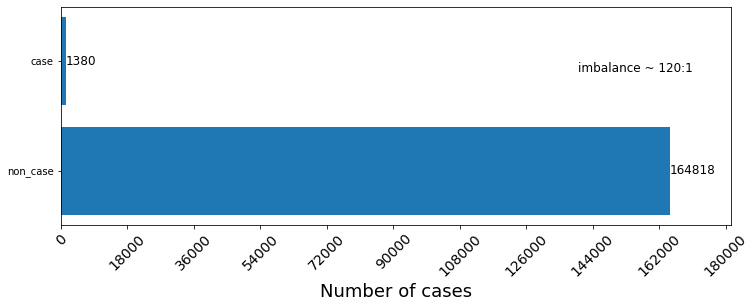

In [20]:
plot_imbalance(df_timeline_converted)

In [21]:
df_timeline.to_csv(f"../data/{NUTS0}_WNV_Cases_2010-2021.csv", encoding = enc, index = False)